# HOUSEKEEPING

In [1]:
import sys
sys.path.append("/scratch/radjoe/Projects/SourceCode/MedSAM2") 

import torch
from training.loss_fns import MultiStepMultiMasksAndIous, MultiStepSingleMasksAndIous
import matplotlib.pyplot as plt


# MAIN TESTS

In [52]:
weight_dict = {
        'loss_mask' : 20,
        'loss_dice': 10,
        'loss_iou': 0,
        'loss_class': 0,
}

In [53]:
def inverse_sigmoid(y, low, high):
    return torch.where(y == 1, torch.tensor(high, dtype=y.dtype), torch.tensor(low, dtype=y.dtype))

In [54]:
def create_circle_mask(height, width, center=None, radius=32):
    # Create coordinate grid
    Y, X = torch.meshgrid(torch.arange(height), torch.arange(width), indexing='ij')

    # Default center: center of the image
    if center is None:
        center = (height // 2, width // 2)
    cy, cx = center

    # Default radius: smallest dimension divided by 4
    if radius is None:
        radius = min(height, width) // 4

    # Calculate distance from center
    dist = (X - cx) ** 2 + (Y - cy) ** 2

    # Create mask: inside circle is 1, outside is 0
    mask = dist <= radius ** 2
    return mask.float()

In [55]:
mask = create_circle_mask(512, 512)
mask = mask.expand(3, 1, 512, 512)
mask.unique()

tensor([0., 1.])

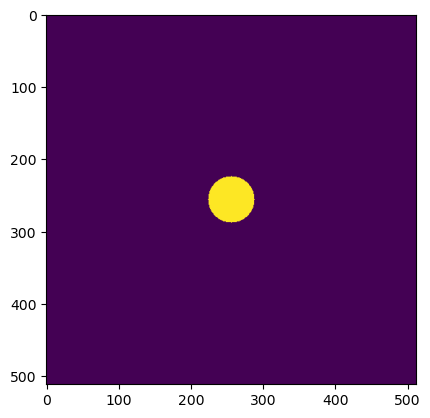

In [56]:
plt.imshow(mask[0][0])

In [79]:
def dummy_inputs(frames = 5, classes = 3, steps = 1, exp_type = 'rand'):    
    H, W = 512, 512
    
    if exp_type == 'rand':
        masks = [inverse_sigmoid(torch.rand(classes, 1, H, W), 20, -1000) for _ in range(steps)]
        ious = [torch.rand(classes, 1) for _ in range(steps)]
        scores = [torch.rand(classes, 1) for _ in range(steps)]

        outs_batch = [{
            "multistep_pred_multimasks_high_res": masks,
            "multistep_pred_ious": ious,
            "multistep_object_score_logits": scores
        }  for _ in range(frames)]

        targets_batch = torch.ones(frames, classes, H, W).float()

    elif exp_type == 'ones':
        masks = [create_circle_mask(H, W, radius=3).expand(1, classes, H, W) for _ in range(steps)]
        ious = [torch.ones(classes, 1) for _ in range(steps)]
        scores = [torch.ones(classes, 1) for _ in range(steps)]

        outs_batch = [{
            "multistep_pred_multimasks_high_res": masks,
            "multistep_pred_ious": ious,
            "multistep_object_score_logits": scores
        }  for _ in range(frames)]

        targets_batch = create_circle_mask(H, W,)
        targets_batch = targets_batch.expand(frames, classes, H, W)

    elif exp_type == 'masks':
        masks = [inverse_sigmoid(create_circle_mask(H, W, radius=40).expand(1, classes, H, W), -14.0938, 12.0234) for _ in range(steps)]
        ious = [torch.ones(classes, 1) for _ in range(steps)]
        scores = [torch.ones(classes, 1) for _ in range(steps)]

        outs_batch = [{
            "multistep_pred_multimasks_high_res": masks,
            "multistep_pred_ious": ious,
            "multistep_object_score_logits": scores
        }  for _ in range(frames)]

        targets_batch = create_circle_mask(H, W,)
        targets_batch = targets_batch.expand(frames, classes, H, W)

    print(f'Target batch shape: {targets_batch.shape, len(outs_batch) ,masks[0].shape}')
    return outs_batch, targets_batch

In [80]:
multimask_loss = MultiStepSingleMasksAndIous(
    weight_dict=weight_dict,
    supervise_all_iou =  True,
    iou_use_l1_loss = True,
    pred_obj_scores =  True,
    focal_gamma_obj_score = 0.0,
    focal_alpha_obj_score = -1.0
    )

In [81]:
output, target = dummy_inputs(exp_type='masks')

Target batch shape: (torch.Size([5, 3, 512, 512]), 5, torch.Size([1, 3, 512, 512]))


In [82]:
multimaskloss = multimask_loss(output, target)

The shape of inputs in sigmoid function: (torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))
tensor(-14.0938) tensor(12.0234)
The shape of inputs in sigmoid function: (torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))
tensor(-14.0938) tensor(12.0234)
The shape of inputs in sigmoid function: (torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))
tensor(-14.0938) tensor(12.0234)
The shape of inputs in sigmoid function: (torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))
tensor(-14.0938) tensor(12.0234)
The shape of inputs in sigmoid function: (torch.Size([1, 3, 512, 512]), torch.Size([1, 3, 512, 512]))
tensor(-14.0938) tensor(12.0234)


In [83]:
print(f'Print the multimaskloss {multimaskloss}')

Print the multimaskloss defaultdict(<class 'int'>, {'loss_mask': tensor(0.3123), 'loss_dice': tensor(3.3081), 'loss_iou': tensor(5.0004), 'loss_class': tensor(0., grad_fn=<AddBackward0>), 'core_loss': tensor(39.3281)})
